In [12]:
%matplotlib inline

# Homework 4

**Pre-homework step**

```
pip install -r requirements.txt
```

## Vision-Language Model (VLM)
Generate Q&A pairs and train a modoel

### Demo Training and Testing

In [28]:
# Train a model on the demo data provided
!python -m homework.finetune demo_train

<frozen runpy>:128: RuntimeWarning: 'homework.finetune' found in sys.modules after import of package 'homework', but prior to execution of 'homework.finetune'; this may result in unpredictable behaviour
trainable params: 3,872,256 || all params: 260,357,184 || trainable%: 1.4873
Loaded 5 QA pairs for train_demo split
  0%|                                                     | 0/5 [00:00<?, ?it/s]`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.
{'loss': 10.7595, 'grad_norm': 86.52445983886719, 'learning_rate': 1e-08, 'epoch': 0.2}
{'loss': 8.1161, 'grad_norm': 121.90704345703125, 'learning_rate': 8e-09, 'epoch': 0.4}
{'loss': 10.7284, 'grad_norm': 146.8580780029297, 'learning_rate': 6e-09, 'epoch': 0.6}
{'loss': 7.1729, 'grad_norm': 39.05646514892578, 'learning_rate': 4e-09, 'epoch': 0.8}
{'loss': 8.2518, 'grad_norm': 53.43437576293945, 'learning_rate': 2e-09, 'epoch': 1.0}
{'train_runtime': 4.9762, 'train_samples_per_second': 1.00

In [29]:
# Benchmark the model with python -m homework.finetune test path/to/your/checkpoint
# Note: path is based on homework.finetune and not the notebook file
# Note: checkpoint path needs to include adapter_config.json and adapter_model.safetensors
!python -m homework.finetune test demo_train/checkpoint-5

<frozen runpy>:128: RuntimeWarning: 'homework.finetune' found in sys.modules after import of package 'homework', but prior to execution of 'homework.finetune'; this may result in unpredictable behaviour
Loaded 120 QA pairs for valid_grader split
  0%|                                                     | 0/4 [00:00<?, ?it/s]	Processed 32 samples
	Questions: ['What kart is the ego car?', 'Is sara_the_racer in front of or behind the ego car?', 'How many karts are in front of the ego car?', 'What track is this?', 'How many karts are there in the scenario?', 'How many karts are there in the scenario?', 'How many karts are to the left of the ego car?', 'Is suzanne to the left or right of the ego car?', 'What kart is the ego car?', 'How many karts are there in the scenario?', 'What kart is the ego car?', 'What track is this?', 'How many karts are to the left of the ego car?', 'Where is xue relative to the ego car?', 'What kart is the ego car?', 'How many karts are there in the scenario?', 'W

### Generate Training Data

Summary
- Process all training images in `data/train/`
- Create your `balanced_qa_pairs.json` file
- Balance question types to avoid model bias

#### Q&A Generation

`generate_qa.py`
- Parse the info.json file to extract kart positions, track info
- Use the provided extract_frame_info and visualization functions
- Generate questions like:
    - "What kart is the ego car?"
    - "How many karts are in the scene?"
    - "Is [kart_name] to the left or right of ego?"
    - "What track is this?"

In [46]:
# Generate Q&A pairs for all training data
%run -m homework.generate_qa generate --info_dir data/train --output_file data/train/balanced_qa_pairs.json

Generating QA pairs for info path "data/train" using data subdirectory: train


Processing frames: 100%|██████████| 5250/5250 [00:18<00:00, 284.99it/s]


Generated 296979 QA pairs and saved to data/train/balanced_qa_pairs.json


In [1]:
# Generate Q&A pairs for all validation data
%run -m homework.generate_qa generate --info_dir data/valid --output_file data/valid/balanced_qa_pairs.json

/home/edo/anaconda3/envs/deeplearn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating QA pairs for info path "data/valid" using data subdirectory: valid


Processing frames: 100%|██████████| 256/256 [00:00<00:00, 276.92it/s]


Generated 15215 QA pairs and saved to data/valid/balanced_qa_pairs.json


#### Classmate's Validator

In [ ]:
import json
from pathlib import Path

qa_balanced = 'balanced_qa_pairs.json'
qa_generated = 'balanced_qa_pairs.json'

def main(path_to_generated: str = None, path_to_balanced: str = None):
    #qa_b = json.load(open(Path(__file__).parent / qa_balanced))
    #qa_g= json.load(open(Path(__file__).parent / qa_generated))
    
    path_b = Path(path_to_balanced)
    path_g = Path(path_to_generated)

    print(f"Loading balanced Q&A pairs from: {path_b / qa_balanced}")
    print(f"Loading generated Q&A pairs from: {path_g / qa_generated}")

    qa_b = json.load(open(path_b / qa_balanced))
    qa_g = json.load(open(path_g / qa_generated))
    
    print(f"Number of qa_pairs golden: {len(qa_b)}")
    print(f"Number of qa_pairs generated: {len(qa_g)}")

    # if every qa_pair in qa_b also exists in qa_g otherwise print it out
    count = 0
    correct = 0
    for idx, qa in enumerate(qa_b):
        found = False
        for qb in qa_g:
            #print("Comparing: " + str(qb["question"]) + " to " + str(qa["question"]))
            if (qb["question"] == qa["question"] and qb["image_file"] == qa["image_file"]):
                found = True
                if qb["answer"] == qa["answer"]:
                    correct+=1
                else:
                    print(f"Wrong answer: {qb}   \nCorrect answer: {qa['answer']}")
                break
        if not found:
            print("Not found: ", qa)
            count+=1
    print(f"Number of qa_pairs missing: {count}  Correct: {correct}")

main(path_to_generated='data/valid', path_to_balanced='data/valid_grader')

Loading balanced Q&A pairs from: data/valid_grader/balanced_qa_pairs.json
Loading generated Q&A pairs from: data/valid/balanced_qa_pairs.json
Number of qa_pairs golden: 120
Number of qa_pairs generated: 15215
Number of qa_pairs missing: 0  Correct: 120


#### View Checker

Drew box for kart id 4 at (60, 46), (70, 55)
Drew box for kart id 5 at (69, 49), (83, 66)
Drew box for kart id 6 at (43, 48), (62, 67)


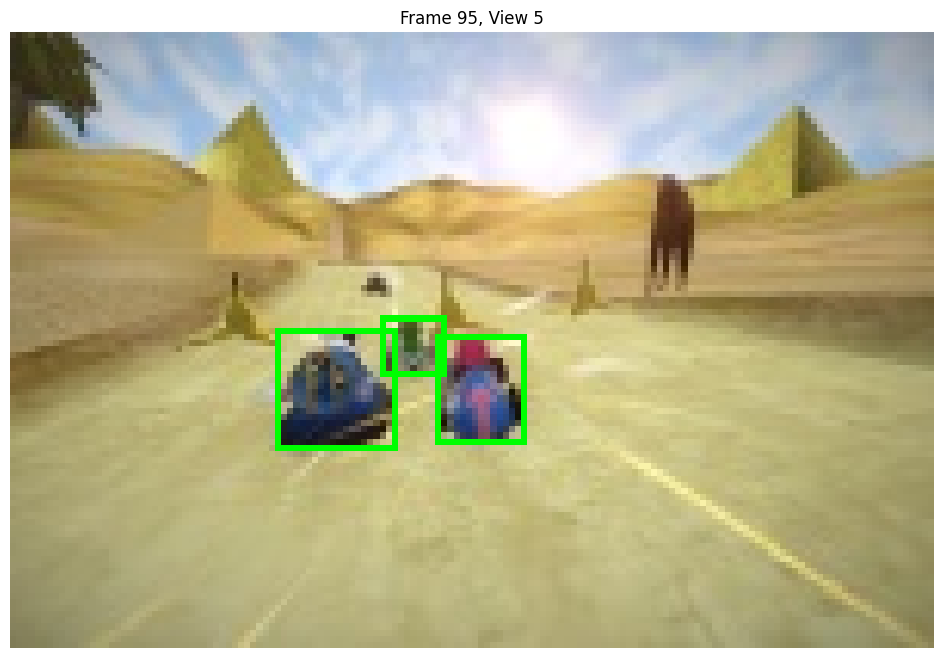

Kart adiumy is front of ego car because its center y-coordinate 50.5 is less than ego car center y-coordinate 57.5
Kart xue is back of ego car because its center y-coordinate 57.5 is greater than ego car center y-coordinate 57.5

Question-Answer Pairs:
--------------------------------------------------
Q: What kart is the ego car?
A: hexley
--------------------------------------------------
Q: How many karts are there in the scenario?
A: 3
--------------------------------------------------
Q: What track is this?
A: sandtrack
--------------------------------------------------
Q: Is adiumy to the left or right of the ego car?
A: left
--------------------------------------------------
Q: Is adiumy in front of or behind the ego car?
A: front
--------------------------------------------------
Q: Where is adiumy relative to the ego car?
A: front and left
--------------------------------------------------
Q: Is xue to the left or right of the ego car?
A: left
---------------------------------

In [35]:
# This shows you what information is available in the SuperTuxKart data for testing Q&A generation
#info_file = 'data/valid/00000_info.json'
#info_file = 'data/train/00baf_info.json'
#info_file = 'data/train/00638_info.json' # view 2
#info_file = 'data/valid/00040_info.json' # view 0
#info_file = 'data/valid/00048_info.json' # view 9
info_file = 'data/valid/0005f_info.json' # view 5
view_index = 5
%run -m homework.generate_qa check --info_file $info_file --view_index $view_index

### Training

In [16]:
""" Train Parameters
    num_train_epochs: int = 0.05,  # use only 0.05 epoch for training
    per_device_train_batch_size: int = 8,
    gradient_accumulation_steps: int = 4,
    learning_rate: float = 5e-4,
    lora_r: int = 8,
    lora_alpha: int = 32,
    lora_dropout: float = 0.0,
    num_workers: int = 16,
"""
# Use default hyperparameters
#%run -m homework.finetune train --output_dir vlm_model

# Use hyperparameters for RTX 3090
!python -m homework.finetune train --output_dir vlm_model \
    #--num_train_epochs 1 \
    --per_device_train_batch_size 16 \
    --gradient_accumulation_steps 2 \
    --num_workers 8

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


<frozen runpy>:128: RuntimeWarning: 'homework.finetune' found in sys.modules after import of package 'homework', but prior to execution of 'homework.finetune'; this may result in unpredictable behaviour
trainable params: 3,872,256 || all params: 260,357,184 || trainable%: 1.4873
Data directory: /home/edo/repo/adv_deep_learning/homework4/data
Loaded 296979 QA pairs for train split
  0%|                                                   | 0/465 [00:00<?, ?it/s]`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.
{'loss': 8.2379, 'grad_norm': 22.439903259277344, 'learning_rate': 0.0005, 'epoch': 0.0}
{'loss': 6.4678, 'grad_norm': 13.158842086791992, 'learning_rate': 0.0004989247311827957, 'epoch': 0.0}
{'loss': 5.2644, 'grad_norm': 9.969298362731934, 'learning_rate': 0.0004978494623655914, 'epoch': 0.0}
{'loss': 4.5311, 'grad_norm': 16.945844650268555, 'learning_rate': 0.0004967741935483871, 'epoch': 0.0}
{'loss': 3.7291, 'grad_norm': 7.

### Testing

Target: 70% accuracy for full points

In [17]:
!python -m homework.finetune test vlm_model

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


<frozen runpy>:128: RuntimeWarning: 'homework.finetune' found in sys.modules after import of package 'homework', but prior to execution of 'homework.finetune'; this may result in unpredictable behaviour
Data directory: /home/edo/repo/adv_deep_learning/homework4/data
Loaded 120 QA pairs for valid_grader split
  0%|                                                     | 0/4 [00:00<?, ?it/s]	Processed 32 samples
	Questions: ['What track is this?', 'What track is this?', 'Where is kiki relative to the ego car?', 'How many karts are there in the scenario?', 'How many karts are in front of the ego car?', 'How many karts are there in the scenario?', 'How many karts are there in the scenario?', 'How many karts are there in the scenario?', 'How many karts are there in the scenario?', 'What kart is the ego car?', 'What kart is the ego car?', 'How many karts are to the left of the ego car?', 'What kart is the ego car?', 'Where is konqi relative to the ego car?', 'What kart is the ego car?', 'Is pu

## Contrastive Language-Image Pre-training (CLIP) Model Caption Generation

### Demo Training and Testing

In [2]:
# Train the CLIP model
!python -m homework.clip demo_train

<frozen runpy>:128: RuntimeWarning: 'homework.clip' found in sys.modules after import of package 'homework', but prior to execution of 'homework.clip'; this may result in unpredictable behaviour
trainable params: 3,769,344 || all params: 224,877,249 || trainable%: 1.6762
Data directory: /home/edo/repo/adv_deep_learning/homework4/data
Loaded 4 captions for train_demo split
  0%|                                                     | 0/2 [00:00<?, ?it/s]`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
{'loss': 0.9751, 'grad_norm': 22.420917510986328, 'learning_rate': 1e-08, 'epoch': 0.5}
{'loss': 0.5585, 'grad_norm': 19.437265396118164, 'learning_rate': 5e-09, 'epoch': 1.0}
{'train_runtime': 2.5393, 'train_samples_per_second': 1.575, 'train_steps_per_second': 0.788, 'train_loss': 0.7667638957500458, 'epoch': 1.0}
100%|█████████████████████████████████████████████| 2/2 [00:02<00:00,  1.27s/it]


In [ ]:
# Test CLIP model with path/to/your/checkpoint
# Note: checkpoint path needs to include adapter_config.json, adapter_model.safetensors, and additional_weights.pt
!python -m homework.clip test demo_clip/checkpoint-5

### Generate Caption
- Generate descriptive captions for images
- Include information about: karts, positions, track, etc.
- Make captions diverse and informative

For Caption Generation (`generate_captions.py`):
- Create descriptive sentences about the scene
- Example: "The ego kart is kart_1 on track_name with 3 other karts visible"
- Vary caption structure for diversity

In [1]:
# Generate captions for all training data
%run -m homework.generate_captions generate --info_dir data/train --output_file data/train/all_captions.json

/home/edo/anaconda3/envs/deeplearn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating captions for info path "data/train" using data subdirectory: train


Processing frames: 100%|██████████| 5250/5250 [00:17<00:00, 294.93it/s]


Generated 249708 captions and saved to data/train/all_captions.json


In [2]:
# Generate captions for all validation data
%run -m homework.generate_captions generate --info_dir data/valid --output_file data/valid/all_captions.json

Generating captions for info path "data/valid" using data subdirectory: valid


Processing frames: 100%|██████████| 256/256 [00:00<00:00, 302.62it/s]


Generated 12759 captions and saved to data/valid/all_captions.json


#### Check


Caption:
--------------------------------------------------
1. suzanne is the ego car.
--------------------------------------------------
2. There are 2 karts in the scenario.
--------------------------------------------------
3. The track is overworld.
--------------------------------------------------
4. kiki is front and left of the ego car.
--------------------------------------------------
Drew box for kart id 1 at (34, 43), (55, 63)
Drew box for kart id 6 at (61, 50), (88, 70)


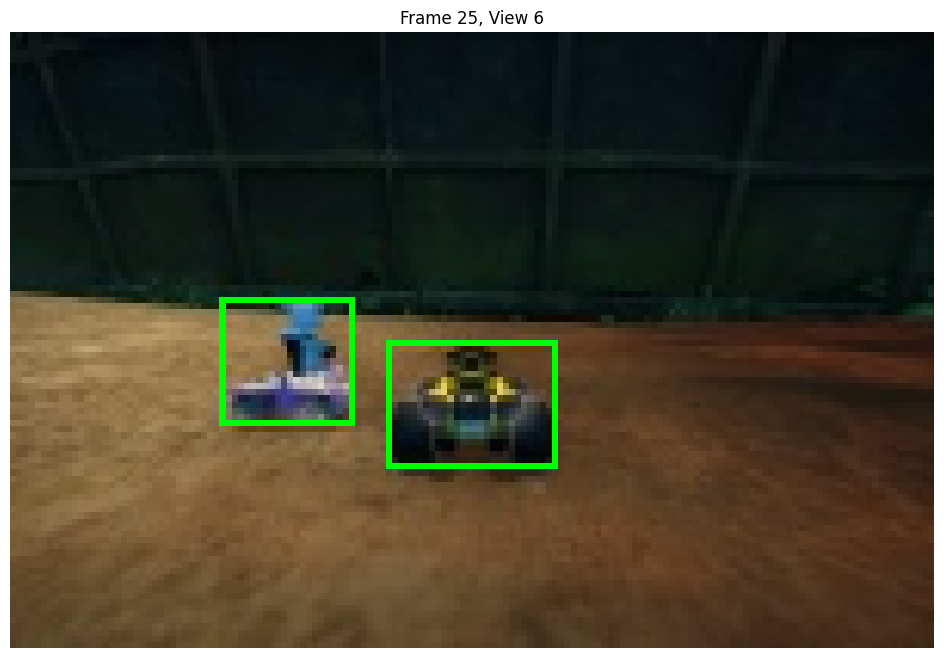

In [16]:
#info_file = 'data/valid/00000_info.json' # view 0
info_file = 'data/valid/00019_info.json' # view 0
view_index = 6

# Test generate caption
%run -m homework.generate_captions check --info_file $info_file --view_index $view_index

#### Classmate's Validator

In [ ]:
def validate_json():
    import json

    captions_balanced = json.load(open(Path("data") / "valid_grader" / "all_mc_qas.json"))
    captions_generated = json.load(open(Path("data") / "valid" / "all_captions.json"))
    #data_dir = Path(__file__).parent.parent
    #captions_files = list(data_dir.glob("data/valid/*_captions.json"))

    """
    for caption_file in captions_files:
        with open(caption_file) as f:
            cap = json.load(f)
            captions_generated.extend(cap)
    """

    print(f"Number of captions golden: {len(captions_balanced)}")
    print(f"Number of captions generated: {len(captions_generated)}")

    generated_by_image = {}
    for cg in captions_generated:
        image_file = cg["image_file"]
        if image_file not in generated_by_image:
            generated_by_image[image_file] = []
        generated_by_image[image_file].append(cg["caption"])
    
    count_missing = 0
    count_correct = 0

    for idx, cb in enumerate(captions_balanced):
        image_file = cb["image_file"]
        correct_caption = cb["candidates"][cb["correct_index"]]

        if image_file not in generated_by_image:
            print(f"Not found: {cb}")
            count_missing += 1
            continue

        if correct_caption in generated_by_image[image_file]:
            count_correct += 1
        else:
            print(f"Wrong answer fpr image {image_file}:\nExpected: {correct_caption}\nGenerated: {generated_by_image[image_file]}")
        
    print(f"Number of missing images: {count_missing}")
    print(f"Number of correct caption matches: {count_correct} of {len(captions_balanced)}")

validate_json()

Number of captions golden: 200
Number of captions generated: 12759
Number of missing images: 0
Number of correct caption matches: 200 of 200


### CLIP Implementation
- Vision encoder setup
- Text encoder setup
- Contrastive loss computation
- Multi-choice Q&A logic

For CLIP (`clip.py`):
- Reuse vision encoder from VLM
- Reuse text encoder (LLM) from VLM
- Implement contrastive loss between image and text embeddings
- For multi-choice: compare image embedding with each caption embedding

### Training

In [1]:
# Train the CLIP model
""" Default train values
    num_train_epochs = 0.05
    per_device_train_batch_size = 1024
    gradient_accumulation_steps = 1
    learning_rate = 5e-4
    num_workers = 16
"""
!python -m homework.clip train --output_dir clip_model

<frozen runpy>:128: RuntimeWarning: 'homework.clip' found in sys.modules after import of package 'homework', but prior to execution of 'homework.clip'; this may result in unpredictable behaviour
trainable params: 3,769,344 || all params: 224,877,249 || trainable%: 1.6762
Data directory: /home/edo/repo/adv_deep_learning/homework4/data
Loaded 249708 captions for train split
  0%|                                                    | 0/13 [00:00<?, ?it/s]

In [ ]:
!python -m homework.clip train --output_dir clip_model \
    --num_train_epochs 1 \
    --per_device_train_batch_size 64 \
    --gradient_accumulation_steps 1 \
    --learning_rate 5e-4 \
    --num_workers 16

<frozen runpy>:128: RuntimeWarning: 'homework.clip' found in sys.modules after import of package 'homework', but prior to execution of 'homework.clip'; this may result in unpredictable behaviour
trainable params: 3,769,344 || all params: 224,877,249 || trainable%: 1.6762
Data directory: /home/edo/repo/adv_deep_learning/homework4/data
Loaded 249708 captions for train split
  0%|                                                  | 0/3902 [00:00<?, ?it/s]`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
{'loss': 4.2573, 'grad_norm': 5.684349536895752, 'learning_rate': 0.0005, 'epoch': 0.0}
{'loss': 4.2156, 'grad_norm': 4.584197044372559, 'learning_rate': 0.0004998718605843158, 'epoch': 0.0}
{'loss': 4.1881, 'grad_norm': 2.566711902618408, 'learning_rate': 0.0004997437211686315, 'epoch': 0.0}
{'loss': 4.2037, 'grad_norm': 1.9657930135726929, 'learning_rate': 0.0004996155817529472, 'epoch': 0.0}
{'loss': 4.1785, 'grad_norm': 1.4675809144973755, 'learnin

### Testing

In [9]:
# Test the CLIP model
#!python -m homework.clip test path/to/checkpoint

!python -m homework.clip test clip_model

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


<frozen runpy>:128: RuntimeWarning: 'homework.clip' found in sys.modules after import of package 'homework', but prior to execution of 'homework.clip'; this may result in unpredictable behaviour
Loaded 200 QA pairs for valid_grader split
100%|█████████████████████████████████████████| 200/200 [00:30<00:00,  6.54it/s]
Accuracy: 0.825


## Common Pitfalls to Avoid

- Don't train on validation data - Use only data/train/
- Watch file size - Keep under 50MB by deleting old checkpoints
- Balance your data - Avoid having 90% of one question type
- Test incrementally - Don't wait until the end to run the grader
- Use the demo - The demo data shows exactly what format is expected

## Grader

In [18]:
!python3 -m grader homework -v

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Val grader loaded.
[INFO     00:02:304] VLM Model Grader
100%|█████████████████████████████████████████████| 4/4 [00:13<00:00,  3.36s/it]
[INFO     00:18:321] Testing accuracy is: 0.758333
[WARNING  00:18:329]   - Test the answer accuracy                           [ 50 / 50  ]
[INFO     00:18:329]  --------------------------------------------------    [  50 /  50 ]
[INFO     00:18:330] CLIP Model Grader
[INFO     00:50:843] Testing accuracy is: 0.825000
[WARNING  00:50:857]   - Test the CLIP accuracy                             [ 52 / 50  ]
[INFO     00:50:857]  --------------------------------------------------    [  52 /  50 ]
[INFO     00:50:857] Total                                                    102 / 100


## Bundle Submission

In [21]:
# bundle homework submission
!python3 bundle.py homework ecc567

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


clip_model
finetune.py
data.py
generate_captions.py
base_vlm.py
__init__.py
clip.py
vlm_model
generate_qa.py
clip_model/training_args.bin
clip_model/events.out.tfevents.1764272320.SD01-PC.27383.1
clip_model/events.out.tfevents.1764220320.SD01-PC.15369.3
clip_model/tensorboard
clip_model/events.out.tfevents.1764220549.SD01-PC.15369.5
clip_model/events.out.tfevents.1764172039.SD01-PC.9796.7
clip_model/events.out.tfevents.1764272812.SD01-PC.28347.1
clip_model/events.out.tfevents.1764224492.SD01-PC.21395.1
clip_model/events.out.tfevents.1764223728.SD01-PC.19593.1
clip_model/events.out.tfevents.1764272913.SD01-PC.28717.1
clip_model/events.out.tfevents.1764261150.SD01-PC.23383.1
clip_model/events.out.tfevents.1764171547.SD01-PC.9796.3
clip_model/events.out.tfevents.1764272465.SD01-PC.27827.1
clip_model/events.out.tfevents.1764217175.SD01-PC.15369.1
clip_model/events.out.tfevents.1764224401.SD01-PC.20713.3
clip_model/events.out.tfevents.1764171617.SD01-PC.9796.5
clip_model/events.out.tfevents

In [22]:
# test submission bundle
!python3 -m grader ecc567.zip

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Val grader loaded.
[INFO     00:02:272] VLM Model Grader
100%|█████████████████████████████████████████████| 4/4 [00:13<00:00,  3.36s/it]
[INFO     00:18:553] Testing accuracy is: 0.750000
[INFO     00:18:561]  * VLM Model Grader                                    [  50 /  50 ]
[INFO     00:18:562] CLIP Model Grader
[INFO     00:53:741] Testing accuracy is: 0.825000
[INFO     00:53:756]  * CLIP Model Grader                                   [  52 /  50 ]
[INFO     00:53:756] Total                                                    102 / 100


# HW4 Data 

Data folder will have train and valid subfolders. Train sub-folder will have 52,500 images and 5,250 json files. Each json file contains information about 10 images in the train sub-folder (this is the same way data is setup in the valid sub-folder). The naming convention is as follows: 

- For the image files: <Frame ID>_<Image/View Index>_im.jpg. E.g. 
    - In 00000_00_im.jpg , FrameID = 00000 and Image/View Index = 00. 
    - In 0000a_01_im.jpg, FrameID = 0000a and Image/View Index = 01
- For the json files: <Frame ID>_info.json
    - In 00000_info.json, FrameID = 00000, and this json file has information about all the images 00000_00_im.jpg, 00000_01_im.jpg, 00000_02_im.jpg, ..... 00000_09_im.jpg,

So, in the example below, for the Frame 00000, we have 10 images and the information about the number of detections in each of these images is available in 00000_info.json.

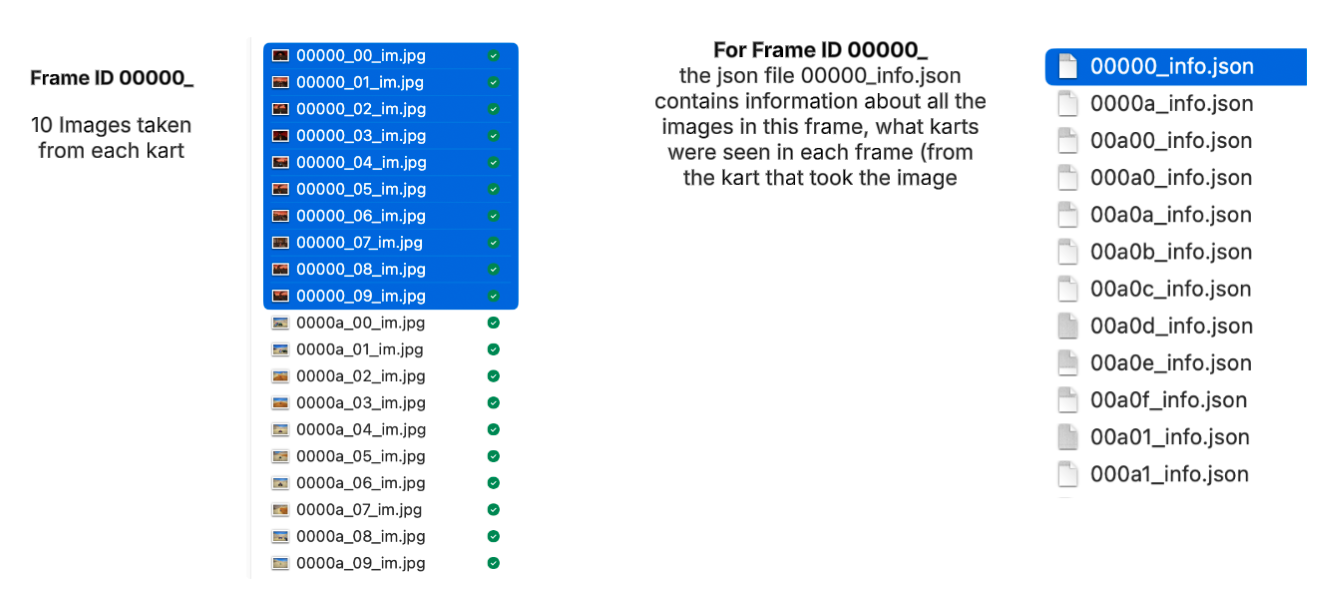

## Structure of the `00000_info.json` File ##

The `00000_info.json` file contains metadata and detection information for a specific frame (frame `00000`) in the dataset. Below is a systematic explanation of its structure and the relationships between its keys and values:

1. **General Structure**

The JSON file contains the following keys:

- “track”: The name of the track where the data was collected (e.g., `"fortmagma"`).
- “karts”: A list of kart names (e.g., `["nolok", "beastie", "sara_the_wizard", ...]`).
- “detections”: A nested list representing detected objects in images taken from the perspective of each kart.
- “distance_down_track”: A list of distances (in meters) for each kart relative to the track.
- “velocity”: A list of velocity vectors for each kart.

2. **Key Details**

- **`karts` Key:** The `karts` key holds a list of kart names. Each kart is assigned a Kart ID, which corresponds to its index in the list:
    - "nolok" → Kart ID 0
    - "beastie" → Kart ID 1
    - "sara_the_wizard" → Kart ID 
    - ...
    - "gnu" → Kart ID 9
- **`detections` Key:** The `detections` key holds a list of lists:
    - The outer list represents the images/views captured by the 10 karts in the frame.
    - Each inner list contains the detected objects in the corresponding image/view.
        - **Detection Object Format:** Each detection object in the inner list is represented as: [Class_ID, Kart_ID, X1, Y1, X2, Y2]
            - **Class_ID:** The type of the detected object. The `Class_ID` corresponds to one of the 6 object types defined in the `OBJECT_TYPES` variable in `generate_qa.py`.
            - **Kart_ID:** The ID of the kart associated with the detected object. This ID corresponds to the index of the kart in the `karts` list.
            - **X1, Y1:** The bottom-left pixel coordinates of the bounding box for the detected object.
            - **X2, Y2:** The top-right pixel coordinates of the bounding box for the detected object.

3. **Kart ID**

- For objects with `Class_ID = 1` (which represents karts), the second index in the detection object corresponds to the Kart ID.
- The Kart ID is always between `0` and `9`, as it corresponds to the index of the kart in the `karts` list.
- Example: **Detection Object [1, 0, 249, 233, 353, 399]:**
    - Class_ID = 1 → This is a kart.
    - Kart_ID = 0 → This corresponds to `"nolok"`, the first kart in the `karts` list.

4. Explanation of Bounding Box Coordinates

The values at positions `2, 3, 4, 5` in the detection object represent the bounding box coordinates:

- X1, Y1: The bottom-left pixel coordinates of the bounding box.
- X2, Y2: The top-right pixel coordinates of the bounding box.
- Example: Detection [1, 0, 249, 233, 353, 399]:
    - X1 = 249, Y1 = 233 → Bottom-left corner of the bounding box.
    - X2 = 353, Y2 = 399 → Top-right corner of the bounding box.

5. **Example: Complete Overview**

In the frame 00000_, lets look at two images/views 00, and 01. Note that as per the example below, Image 00 has 13 object detections and Image 01 has 10 object detections. As mentioned above, not all are karts. We only focus on the kart objects in the example below to see how to interpret Class ID, Kart ID and Coordinates 

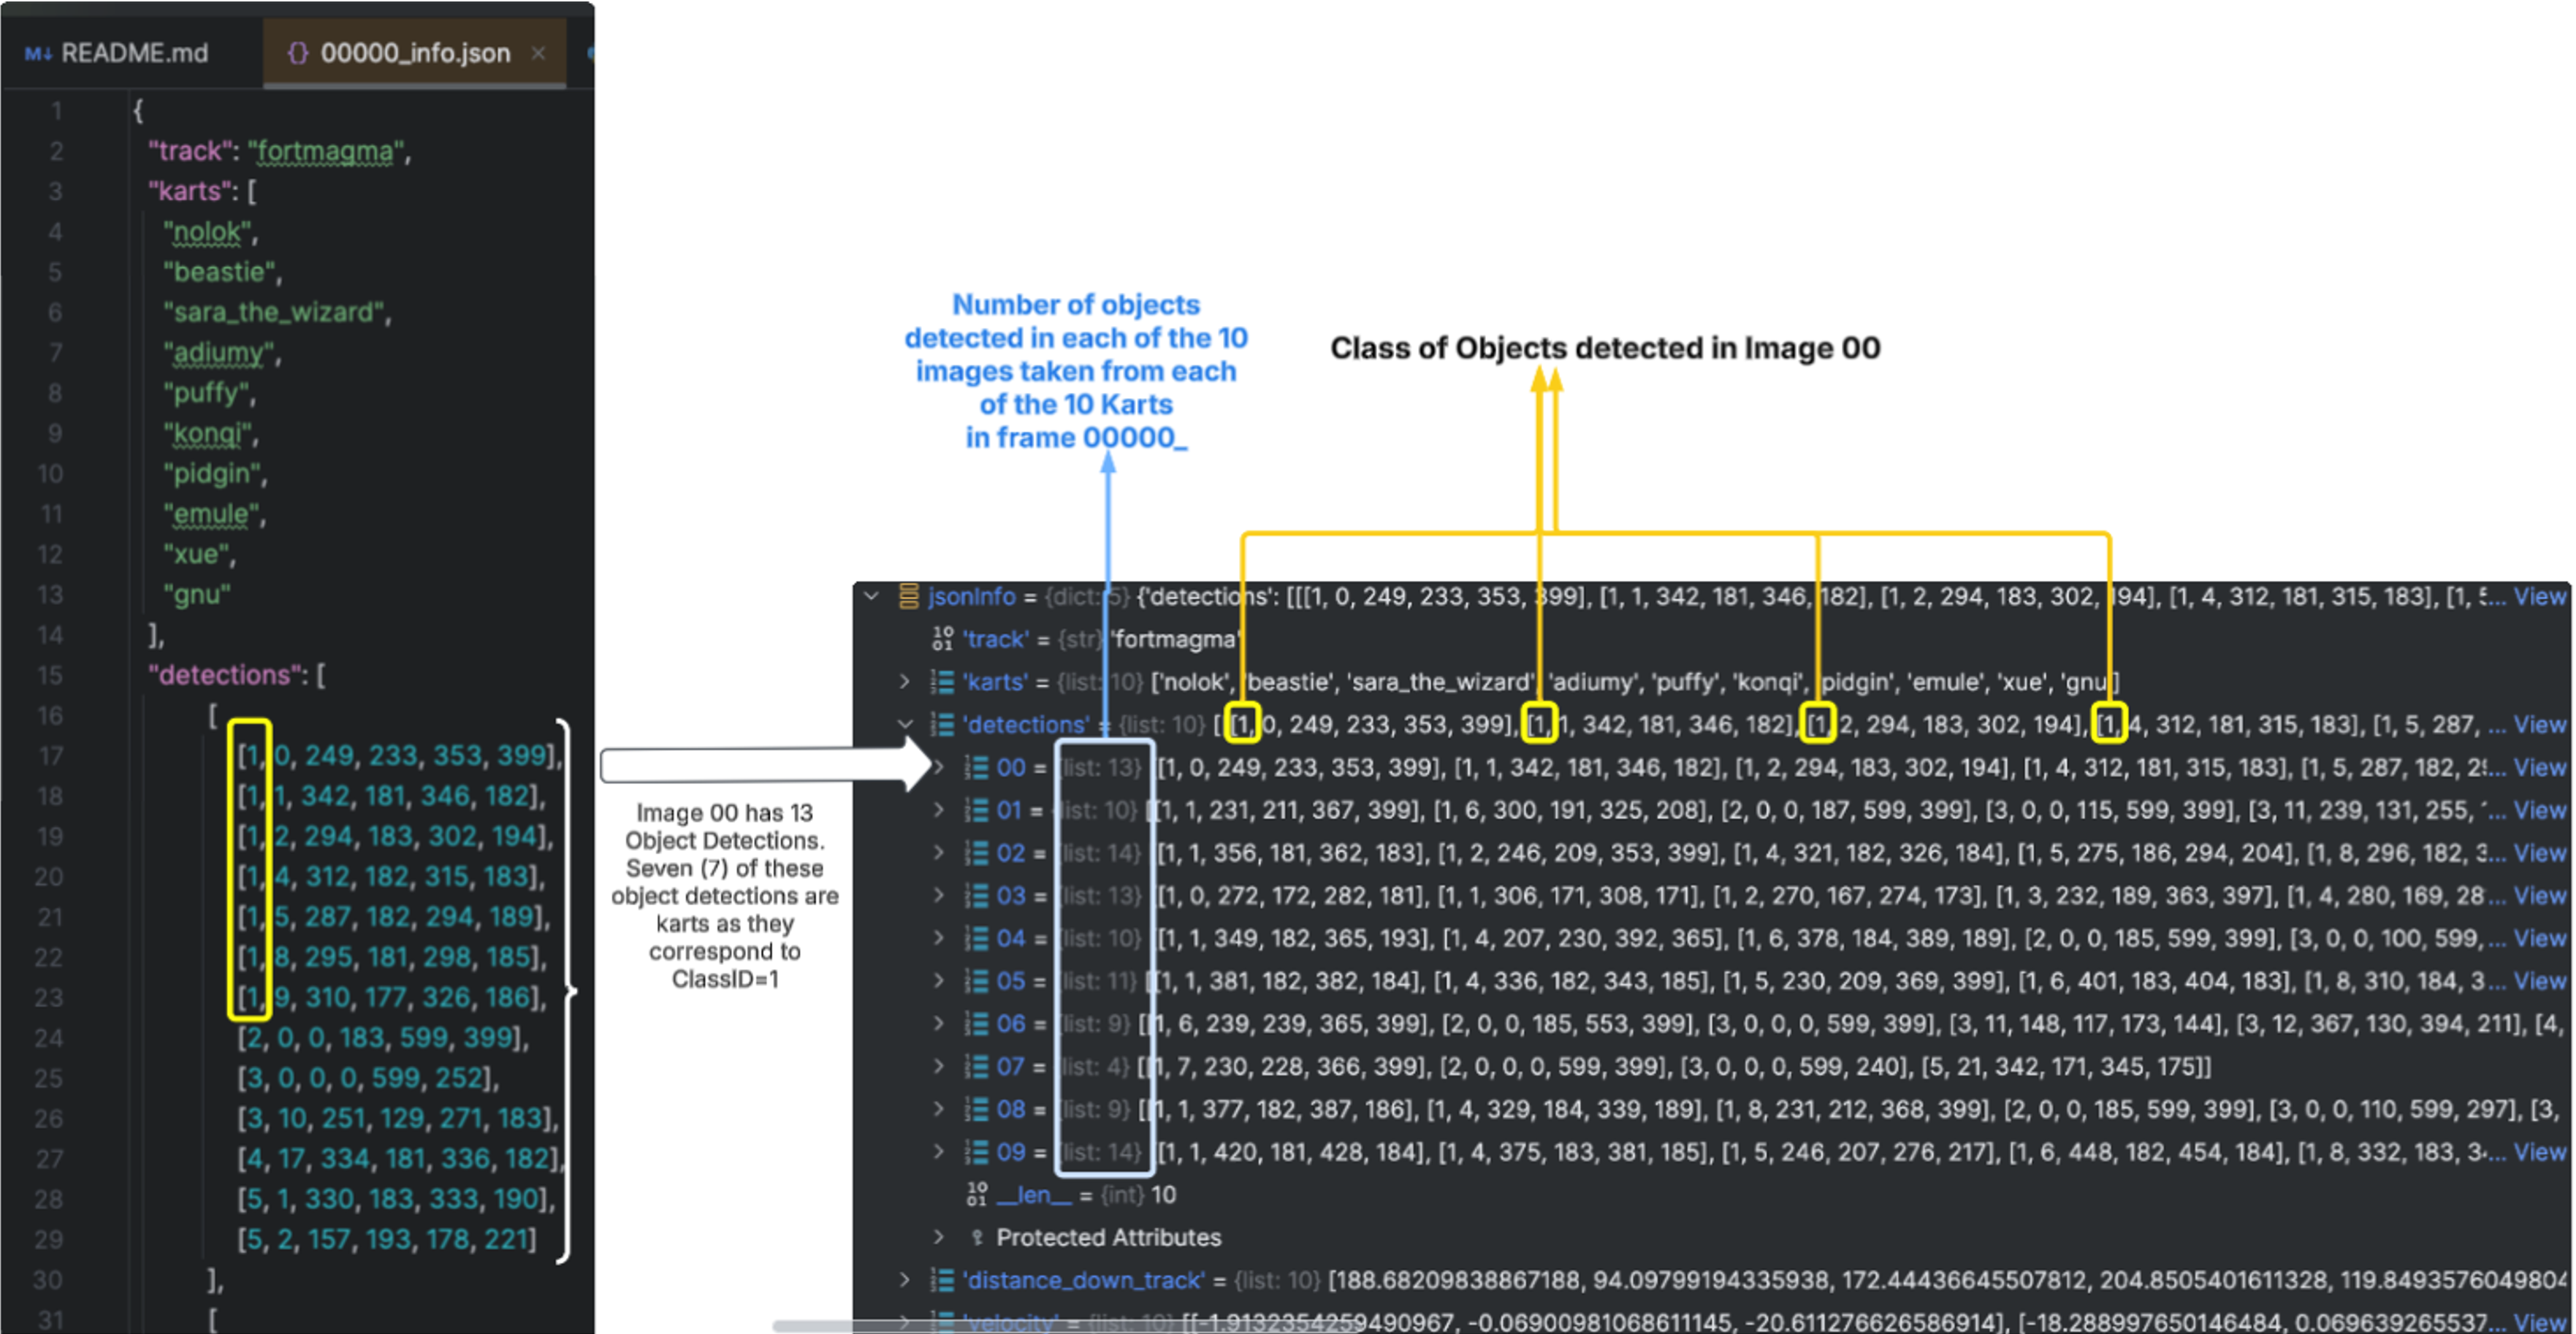

**Image 00** - In Image 00 there were 13 objects detected (example above), and 7 of these objects are kart objects as they correspond to class ID =1. These 7 objects are highlighted by yellow box.

- Detections: [[1, 0, 249, 233, 353, 399], [1, 1, 342, 181, 346, 182], ...]
    1. Detection Object [1, 0, 249, 233, 353, 399]:
        - Class_ID = 1 → This is a kart.
        - Kart_ID = 0 → This corresponds to "nolok".
        - Bounding Box:
            - Bottom-left: (249, 233)
            - Top-right: (353, 399)
    2. Detection Object [1, 1, 342, 181, 346, 182]
        - ....
    3. ...
    4. ...
    5. ...

**Image 01**

- Detections: [[1, 1, 231, 211, 367, 399], ...]
    1. Detection Object [1, 1, 231, 211, 367, 399]:
        - Class_ID = 1 → This is a kart.
        - Kart_ID = 1 → This corresponds to "beastie".
        - Bounding Box:
            - Bottom-left: (231, 211)
            - Top-right: (367, 399)
    2. Detection Object ....

Finally, Note that the coordinates in the JSON file are corresponding to IMAGE SIZE 600 x 400. The Image provided in the train dataset is reduced resolution, of size 150 x 100. The draw detections method in generate_qa.py shows how one could scale the coordinates to 150 x100 dimension. The scaled "detection object bounding box coordinates" can be used to calculate kart center, and those kart centers can then be used to determine which kart is to the left, right, front, behind as per the rule below.

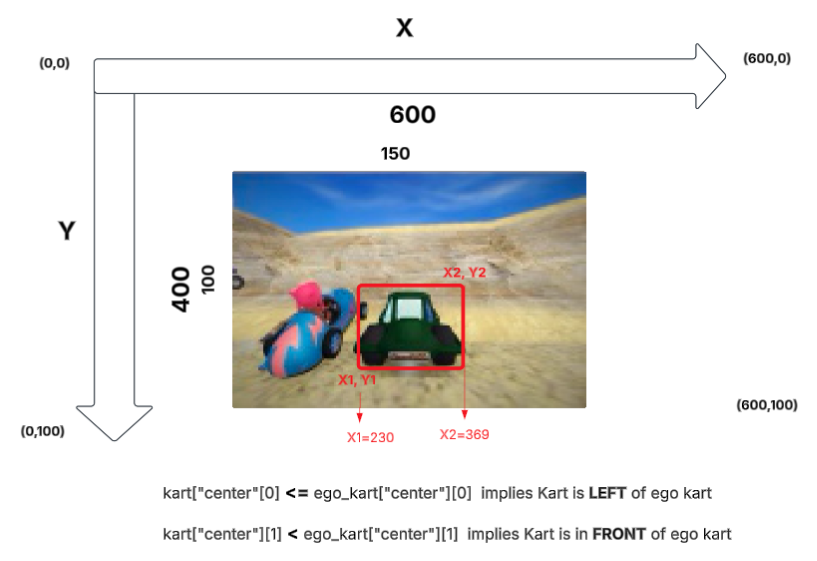

**KEY NOTE ABOUT KART_ID - Note that Kart ID is different across different json files.**

In each frame, you can observe different karts (list of karts in the frame shown in "karts" key). For example, as shown below Frame=00000 has different list of karts observed across the 10 images/views in this frame, compared to Frame=0000a. The kart_id for "kart=puffy" is '4' in Frame=00000 and '0' in Frame=0000a. You extract kart_name using the kart_id in each frame's json. Also, not that in generate_qa.py > draw_detections, **this kart_id is read into the variable track_id. So when extracting kart names, use kart_names[track_id], if you are following the same naming convention for variables in extract_kart_objects() method.**

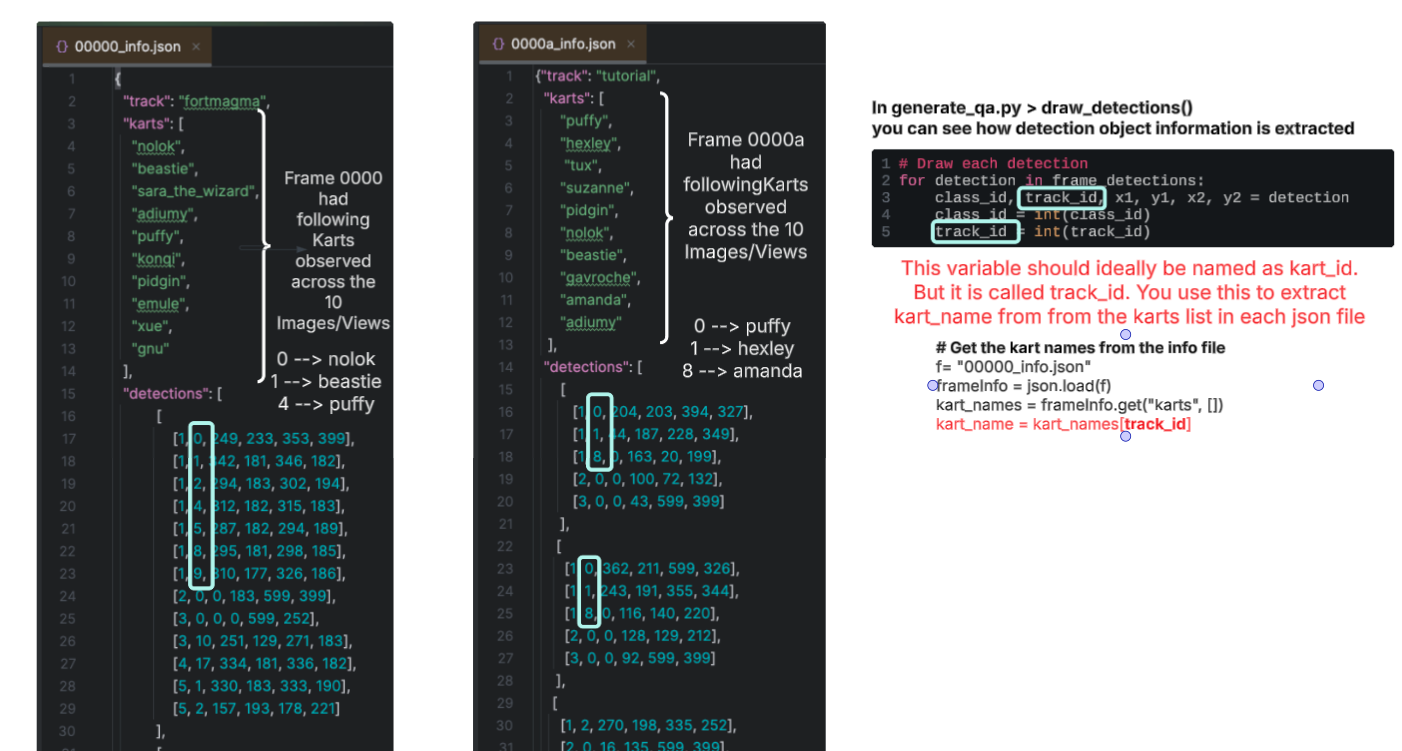



# Time Estimation

Time Estimates

Understanding/Setup: 30 min

VLM Q&A: 3-4 hours

CLIP: 2-3 hours

Training/Tuning: 2-3 hours

Total: ~8-11 hours